<a href="https://colab.research.google.com/github/Odinokiy0605/week7lab/blob/main/KNN_NumPy_vs_ScikitLearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KNN Algorithm using NumPy and Scikit-learn

Code KNN from scratch with NumPy • Compare with Scikit-learn • Visualizations • K Selection (Elbow Method) • Exercises (Marked)

---
## 1. Introduction

**K-Nearest Neighbors (KNN)** is a simple, instance-based (lazy) learning algorithm. Unlike eager learners that build a model during training, KNN defers all computation until prediction time: given a new point, it finds the *k* training examples closest to it (by some distance, usually Euclidean) and assigns the majority class among those neighbors. No explicit model is learned—the "model" is the entire training set.

Because KNN is **distance-based**, the choice of distance metric (Euclidean, Manhattan, Minkowski) and, crucially, the value of **k** strongly affect performance. Too small *k* leads to overfitting and noise sensitivity; too large *k* can underfit and blur class boundaries. Thus **k selection** (e.g., via elbow method or cross-validation) is essential.

In this lab we **implement KNN from scratch using only NumPy** on a simple 2D synthetic dataset, then solve the **same problem with Scikit-learn** and compare accuracy, parameters, and visualizations (decision boundaries, accuracy vs *k*). We also cover **k selection methods** and end with **marked exercises** on a 3-class dataset, sklearn comparison, and a real-world dataset.

---
## 6. Lab Exercises (Total 100 marks)

Complete the following in the cells below. Marks are indicated for each part.

### Part 1 (50 marks) – More Complex Dataset with NumPy

**Dataset:** Prepared in the cells below: **X_train_ex1**, **X_test_ex1**, **y_train_ex1**, **y_test_ex1** (3-class, 2 features, raw). **X_ex1**, **y_ex1** are the full data for decision-boundary plots.

**Instructions:**  
- **Apply min-max normalization** (fit on train, transform train and test) before fitting KNN.
- Implement **full KNN from scratch** using only NumPy (distance function, majority voting, prediction). You can adapt the **KNN_NumPy** class from Part A to handle 3 classes.
- Compute **accuracy**.
- **Write your code in the cell below.**

### Dataset for Part 1 & Part 2 (3-class, ready to use)

Run the cell below once. It generates a 3-class dataset with `make_blobs`, splits into train/test, and visualizes it. Use **X_train_ex1**, **X_test_ex1**, **y_train_ex1**, **y_test_ex1** in your code. **X_ex1**, **y_ex1** are the full data for decision-boundary plots. **Normalization (min-max) is left for you to implement in the exercise.**

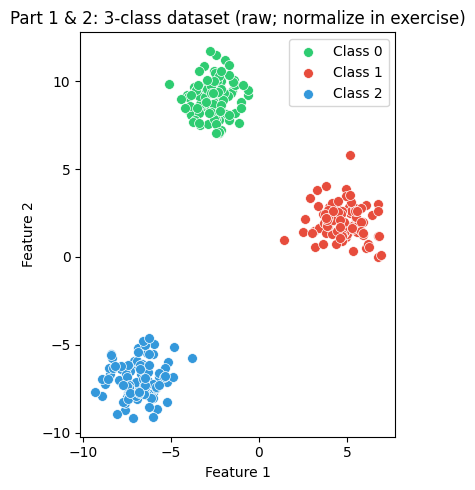

Part 1 & 2 dataset ready: 3 classes, 2 features (raw). Apply min-max normalization in your code.
Variables: X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1, X_ex1, y_ex1
Train: 240 | Test: 60 | Classes: 3


In [10]:
# 3-class dataset for Part 1 and Part 2 (generated and split; normalization left for exercise)
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

X_ex1_raw, y_ex1 = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)
X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1 = train_test_split(
    X_ex1_raw, y_ex1, test_size=0.2, random_state=42, stratify=y_ex1
)
X_ex1 = np.vstack([X_train_ex1, X_test_ex1])
y_ex1 = np.hstack([y_train_ex1, y_test_ex1])
fig, ax = plt.subplots(figsize=(7, 5))
colors_ex1 = ['#2ecc71', '#e74c3c', '#3498db']
for cls in range(3):
    mask = y_ex1 == cls
    ax.scatter(X_ex1[mask, 0], X_ex1[mask, 1], c=colors_ex1[cls], label=f'Class {cls}', s=50, edgecolors='white', linewidths=0.5)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Part 1 & 2: 3-class dataset (raw; normalize in exercise)')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print("Part 1 & 2 dataset ready: 3 classes, 2 features (raw). Apply min-max normalization in your code.")
print("Variables: X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1, X_ex1, y_ex1")
print("Train:", X_train_ex1.shape[0], "| Test:", X_test_ex1.shape[0], "| Classes:", len(np.unique(y_ex1)))

### Part 2 (30 marks) – Same Dataset with Scikit-learn

**Dataset:** Use the same data as Part 1: **X_train_ex1**, **X_test_ex1**, **y_train_ex1**, **y_test_ex1**, and **X_ex1**, **y_ex1** for decision-boundary plots.

**Instructions:**  
- Fit **KNeighborsClassifier** on the same train set and predict on the test set.
- Compare accuracy with your Part 1 NumPy implementation.
- Show **decision boundary** and tune **K** using elbow method or `GridSearchCV`.
- **Write your code in the cell below.**

Scikit-learn KNN Accuracy (k=5): 1.0000
Run Part 1 to compare accuracies.
Best K: 1
Best CV Score: 1.0


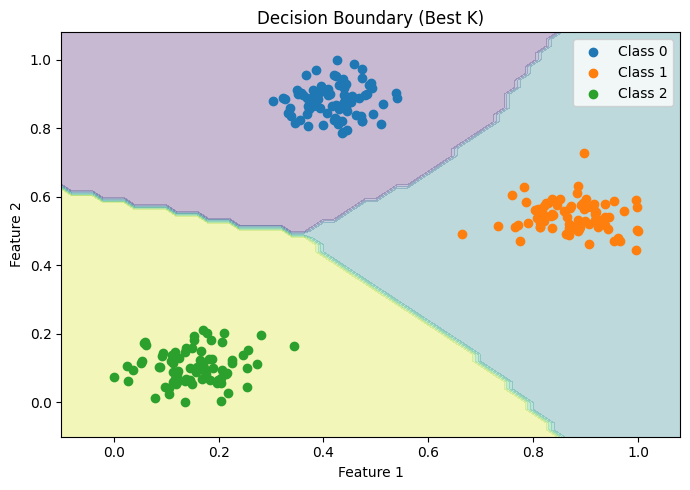

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
X_min = X_train_ex1.min(axis=0)
X_max = X_train_ex1.max(axis=0)
epsilon = 1e-8

X_train_norm = (X_train_ex1 - X_min) / (X_max - X_min + epsilon)
X_test_norm  = (X_test_ex1  - X_min) / (X_max - X_min + epsilon)
knn_sklearn = KNeighborsClassifier(n_neighbors=5)
knn_sklearn.fit(X_train_norm, y_train_ex1)
y_pred_sklearn = knn_sklearn.predict(X_test_norm)
acc_sklearn = accuracy_score(y_test_ex1, y_pred_sklearn)
print(f"Scikit-learn KNN Accuracy (k=5): {acc_sklearn:.4f}")
try:
    print(f"NumPy KNN Accuracy (Part 1): {accuracy:.4f}")
except:
    print("Run Part 1 to compare accuracies.")
param_grid = {'n_neighbors': list(range(1, 21))}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_norm, y_train_ex1)

print("Best K:", grid.best_params_['n_neighbors'])
print("Best CV Score:", grid.best_score_)
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

    # Scatter original points
    for cls in np.unique(y):
        plt.scatter(X[y == cls, 0], X[y == cls, 1], label=f"Class {cls}")

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Train best model for visualization
best_knn = grid.best_estimator_
plot_decision_boundary(best_knn, X_train_norm, y_train_ex1,
                       "Decision Boundary (Best K)")

### Dataset for Part 3 (real-world, ready to use)

Run the cell below once. It loads **Breast Cancer**, splits into train/test with stratification, and visualizes it (first two features). Use **X_train_ex3**, **X_test_ex3**, **y_train_ex3**, **y_test_ex3**. **target_names_ex3** and **feature_names_ex3** are available for labels. **X_train_ex3_2d**, **X_test_ex3_2d** are the first two features (for 2D plots). **Normalization (min-max) is left for you to implement in the exercise.**

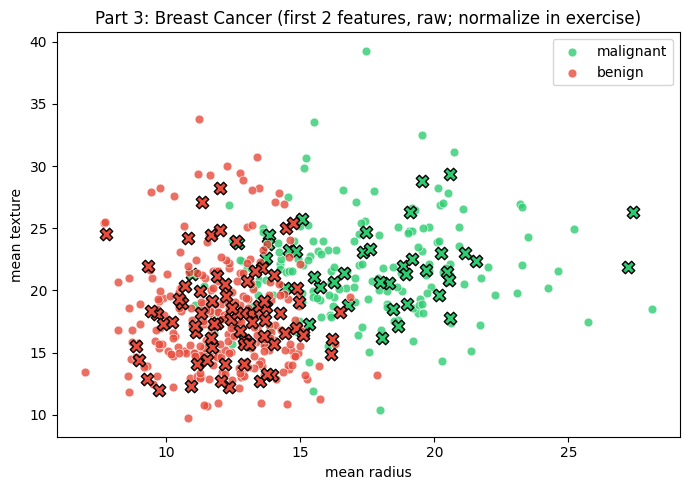

Part 3 dataset ready: Breast Cancer, 30 features (raw). Apply min-max normalization in your code.
Variables: X_train_ex3, X_test_ex3, y_train_ex3, y_test_ex3, X_train_ex3_2d, X_test_ex3_2d
Train: 455 | Test: 114 | Classes: ['malignant', 'benign']
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix:
[[40  2]
 [ 0 72]]


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Dataset for Part 3 (real-world, ready to use) ---
bc = load_breast_cancer()
X_ex3_raw = bc.data
y_ex3 = bc.target
feature_names_ex3 = np.array(bc.feature_names)
target_names_ex3 = np.array(bc.target_names)

X_train_ex3, X_test_ex3, y_train_ex3, y_test_ex3 = train_test_split(
    X_ex3_raw, y_ex3, test_size=0.2, random_state=42, stratify=y_ex3
)
# First two features for 2D visualization and decision-boundary plots
X_train_ex3_2d = X_train_ex3[:, :2]
X_test_ex3_2d = X_test_ex3[:, :2]

# Visualize generated dataset (first 2 features, colored by class)
fig, ax = plt.subplots(figsize=(7, 5))
colors_ex3 = ['#2ecc71', '#e74c3c']  # benign, malignant
for cls in range(2):
    mask_train = y_train_ex3 == cls
    mask_test = y_test_ex3 == cls
    ax.scatter(X_train_ex3_2d[mask_train, 0], X_train_ex3_2d[mask_train, 1], c=colors_ex3[cls],
              label=target_names_ex3[cls], s=40, alpha=0.8, edgecolors='white', linewidths=0.5)
    ax.scatter(X_test_ex3_2d[mask_test, 0], X_test_ex3_2d[mask_test, 1], c=colors_ex3[cls], s=80, marker='X', edgecolors='black')
ax.set_xlabel(feature_names_ex3[0])
ax.set_ylabel(feature_names_ex3[1])
ax.set_title('Part 3: Breast Cancer (first 2 features, raw; normalize in exercise)')
ax.legend()
plt.tight_layout()
plt.show()

print("Part 3 dataset ready: Breast Cancer, 30 features (raw). Apply min-max normalization in your code.")
print("Variables: X_train_ex3, X_test_ex3, y_train_ex3, y_test_ex3, X_train_ex3_2d, X_test_ex3_2d")
print("Train:", X_train_ex3.shape[0], "| Test:", X_test_ex3.shape[0], "| Classes:", target_names_ex3.tolist())

# --- 1. Min-Max Normalization (fit on train only) ---
X_min = X_train_ex3.min(axis=0)
X_max = X_train_ex3.max(axis=0)
epsilon = 1e-8

X_train_norm = (X_train_ex3 - X_min) / (X_max - X_min + epsilon)
X_test_norm  = (X_test_ex3  - X_min) / (X_max - X_min + epsilon)

# --- 2. Train KNN ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_norm, y_train_ex3)

# --- 3. Predict ---
y_pred = knn.predict(X_test_norm)

# --- 4. Evaluation ---
accuracy = accuracy_score(y_test_ex3, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_ex3, y_pred, target_names=target_names_ex3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_ex3, y_pred))

### Part 3 (20 marks) – Real-World Dataset

**Dataset:** Prepared above: **X_train_ex3**, **X_test_ex3**, **y_train_ex3**, **y_test_ex3** (Breast Cancer, raw). Use **X_train_ex3_2d**, **X_test_ex3_2d** for 2D plots; **target_names_ex3**, **feature_names_ex3** for labels.

**Instructions:**  
- **Apply min-max normalization** (fit on train, transform train and test) before fitting KNN.
- Implement KNN with **sklearn**, find **best K** using elbow or cross-validation.
- Report **accuracy**.
- **Write your code and short analysis in the cell(s) below.**

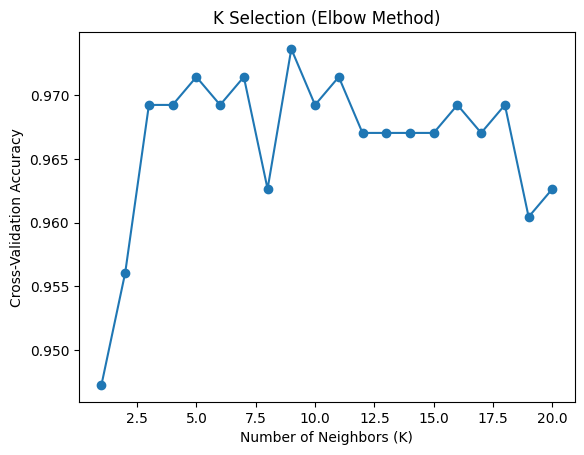

Best K: 9
Test Accuracy: 0.9649122807017544


In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_ex3)
X_test_scaled = scaler.transform(X_test_ex3)

k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train_ex3, cv=5)
    cv_scores.append(scores.mean())

plt.figure()
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('K Selection (Elbow Method)')
plt.show()


best_k = k_values[np.argmax(cv_scores)]
print("Best K:", best_k)

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train_ex3)

y_pred = knn_best.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test_ex3, y_pred)

print("Test Accuracy:", test_accuracy)

---
## 7. Conclusion & Submission

**Key learnings:**  
- KNN is a lazy, distance-based classifier; *k* and the distance metric matter.  
- Implementing KNN from scratch with NumPy (Euclidean distance + majority vote) matches sklearn for the same settings.  
- Scikit-learn provides fast, tunable KNN with options for weights, metric, and algorithm.  
- K can be chosen via the **elbow method** (accuracy vs *k*) or **cross-validation** / **GridSearchCV**.  
- Decision boundaries and accuracy-vs-K plots help interpret and tune the model.
